In [2]:
import calendar
import string
from enum import Enum, auto
from itertools import pairwise
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib import colormaps as cmaps  # pyright: ignore[reportAttributeAccessIssue]
from scipy.stats import distributions
from tqdm import tqdm

In [9]:
# For plotting months with colormap
colors = cmaps["viridis"](np.linspace(0, 1, 6))

In [3]:
NOTEBOOK_DIR = Path().cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
VEL_PATH = DATA_DIR / "NH10_Mooring_Data/nh10_hourly_data_1997_2023_rotated_filtered_streamwise_v4.nc"
OLD_VEL_PATH = list(
    Path(DATA_DIR / "NH10_Mooring_Data/").glob("nh10_hourly_data_1997_2021_part*.nc"),
)
NEW_VEL_PATH = DATA_DIR / "NH10_Mooring_Data/ADCP_NH10_1997_2024_V5.nc"

VELOCITY_VARIABLE = "cs"

In [4]:
MIN_VEL_DEPTH = 10  # meters
MAX_VEL_DEPTH = 80  # meters

inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
velocity = xr.open_dataset(VEL_PATH)

# bit of a lazy way to use the cs_proj variable, since the notebook is set up for cs
if VELOCITY_VARIABLE == "cs_proj":
    velocity = velocity.drop_vars("cs").rename({"cs_proj": "cs"})

# resample midshelf nitrate to fill some of the gaps for composite calclulations
midshelf_nitrate = midshelf_nitrate.resample(time="1D").mean()

# interpolate velocity depths to match 1 meter bins in midshelf nitrate
velocity = velocity.interp(depth=midshelf_nitrate.depth)
velocity = velocity.resample(time="1D").mean()
velocity = velocity.where((velocity.depth > MIN_VEL_DEPTH) & (velocity.depth < MAX_VEL_DEPTH))

GLOBEC_TIME = slice(np.datetime64("1997-01-01"), np.datetime64("2004-12-31"))
NANOOS_TIME = slice(np.datetime64("2006-07-01"), np.datetime64("2014-09-30"))
OOI_TIME = slice(np.datetime64("2015-04-01"), None)

# velocity = velocity.sel(time=OOI_TIME)

## Computing Composites Based on Wind Stress

In [13]:
WIND_MIN, WIND_MAX = -0.05, -0.03
days = np.arange(-5, 6)
composite_wind_events = []
for t1, t2 in pairwise(tqdm(wind["time"], desc="Finding Wind Stress Events")):
    wind_t1 = wind.sel({"time": t1})
    wind_t2 = wind.sel({"time": t2})
    # find times when wind switches from above 0.03 to below -0.05
    if (wind_t2.coare_y < WIND_MIN) & (wind_t1.coare_y > WIND_MAX):
        wind_slice = wind.sel(time=slice(t2, t2 + np.timedelta64(5, "D")))
        # only include events that have upwelling favorable winds for at least 5 days after initial change
        if np.all(wind_slice.coare_y < 0):
            composite_wind_events.append(
                wind.sel(
                    time=slice(t2 - np.timedelta64(5, "D"), t2 + np.timedelta64(5, "D")),
                ),
            )
            # drop unnecessary variables
            composite_wind_events[-1] = composite_wind_events[-1].drop_vars(
                ["dominant_wpd", "average_wpd"],
            )
# select only composites with the full amount of time points (11)
composite_wind_events = [c for c in composite_wind_events if len(c.time) == len(days)]
composite_vel_events = [velocity.where(velocity.time.isin(cw.time), drop=True) for cw in composite_wind_events]
composite_vel_events = [cv for cv in composite_vel_events if cv.time.size == len(days)]
# do the same for midshelf nitrate, but note that with the resampling a lot of NaN values are still included here
composite_midshelf_nitrate_events = [
    midshelf_nitrate.where(midshelf_nitrate["time"].isin(cw.time), drop=True) for cw in composite_wind_events
]
composite_midshelf_nitrate_events = [cmn for cmn in composite_midshelf_nitrate_events if cmn.time.size == len(days)]

# deal with overlapping events
# if the time between events is less than 5 days, combine them
composite_times = [c.time[5].values for c in composite_wind_events]
for i, (t1, t2) in enumerate(
    pairwise(composite_times),
):
    if t2 - t1 < np.timedelta64(5, "D"):
        composite_wind_events[i] = composite_wind_events[i].sel(
            time=slice(None, t2 - np.timedelta64(1, "D")),
        )
composite_times = [c.time[5].values for c in composite_vel_events]
for i, (t1, t2) in enumerate(
    pairwise(composite_times),
):
    if t2 - t1 < np.timedelta64(5, "D"):
        composite_vel_events[i] = composite_vel_events[i].sel(
            time=slice(None, t2 - np.timedelta64(1, "D")),
        )
composite_times = [c.time[5].values for c in composite_midshelf_nitrate_events]
for i, (t1, t2) in enumerate(
    pairwise(composite_times),
):
    if t2 - t1 < np.timedelta64(5, "D"):
        composite_midshelf_nitrate_events[i] = composite_midshelf_nitrate_events[i].sel(
            time=slice(None, t2 - np.timedelta64(1, "D")),
        )

Finding Wind Stress Events: 100%|██████████| 11642/11642 [00:41<00:00, 280.18it/s]


In [14]:
# different because the velocity data does not span as far back as wind data
n = len(composite_wind_events)
print(f"Number of composite wind events: {n}")
n = len(composite_vel_events)
print(f"Number of composite velocity events: {n}")
n = len(composite_midshelf_nitrate_events)
print(f"Number of composite midshelf nitrate events: {n}")

Number of composite wind events: 222
Number of composite velocity events: 185
Number of composite midshelf nitrate events: 74


In [15]:
class CompositeType(Enum):
    """Enum for composite type, either monthly or daily."""

    MONTHLY = auto()
    ANNUAL = auto()


def composite(
    events: list[xr.Dataset],
    var: str,
    composite_days: np.ndarray,
    composite_type: CompositeType = CompositeType.ANNUAL,
) -> xr.Dataset:
    """Take a list of events and compute monthly or annual composites.

    Events are a list of datasets, each of which contains one event, over a event length defined by composite_days.

    Args:
        events (list[xr.Dataset]): list of datasets containing each event to composite
        var (str): variable to composite
        composite_days (np.ndarray): composite days, typically a range of days around an event (e.g., -5 to 5)
        composite_type (CompositeType): compute annual or monthly composite,
            either CompositeType.MONTHLY or CompositeType.ANNUAL, defaults to CompositeType.ANNUAL

    Returns:
        ds (xr.Dataset): dataset containing mean, std, count, and confidence interval for composite

    """
    composite_length = composite_days.size
    ds_list = np.empty(composite_length, dtype=xr.Dataset)
    # for each day in the composite length, combine each event to get the mean, std, and number of data points (count)
    for i in range(composite_length):
        composite_data = [d.isel(time=i) for d in events if len(d.time) == composite_length]
        composite_data = xr.concat(composite_data, dim="time")
        if composite_type == CompositeType.MONTHLY:
            composite_mean = composite_data.groupby("time.month").mean(
                dim="time",
                skipna=True,
            )[var]
            composite_std = composite_data.groupby("time.month").std(
                dim="time",
                skipna=True,
            )[var]
            composite_count = composite_data.groupby("time.month").count(dim="time")[var]
            ds_list[i] = xr.Dataset(
                {
                    "mean": composite_mean,
                    "std": composite_std,
                    "count": composite_count,
                },
                coords={"time": composite_days[i]},
            )
        else:
            composite_mean = composite_data.mean(dim="time", skipna=True)[var]
            composite_std = composite_data.std(dim="time", skipna=True)[var]
            composite_count = composite_data.count(dim="time")[var]
            ds_list[i] = xr.Dataset(
                {
                    "mean": composite_mean,
                    "std": composite_std,
                    "count": composite_count,
                },
            )
    ds = xr.concat(ds_list, dim="time")
    ds["ci"] = ds["std"] / np.sqrt(ds["count"]) * distributions.t(ds["count"] - 1).isf(0.025)
    return ds

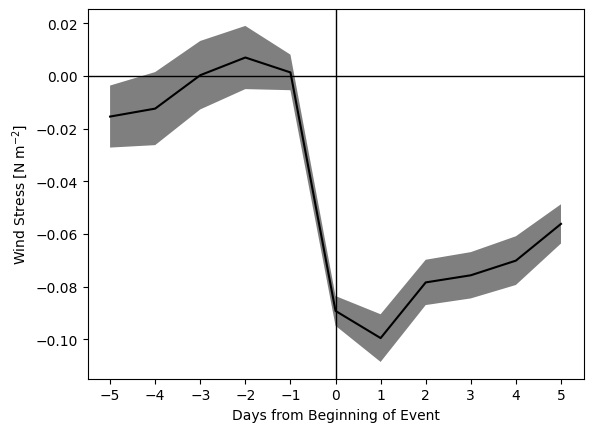

In [16]:
composite_stress = composite(composite_wind_events, "coare_y", days)

fig, ax = plt.subplots()

ax.plot(days, composite_stress["mean"], color="black", label="Median")
# For some reason, pyright thinks that this should only take in scalars, despite matplotlib docs saying otherwise
ax.fill_between(
    days,
    composite_stress["mean"] - composite_stress["ci"],  # pyright: ignore[reportArgumentType]
    composite_stress["mean"] + composite_stress["ci"],  # pyright: ignore[reportArgumentType]
    ls="None",
    edgecolor="None",
    facecolor="black",
    alpha=0.5,
)

ax.set_xticks(np.arange(-5, 6))
ax.minorticks_off()
ax.set_xlabel("Days from Beginning of Event")
ax.set_ylabel("Wind Stress [$\\mathsf{N} \\; \\mathsf{m^{-2}}$]")
ax.axhline(0, color="black", ls="-", lw=1)
ax.axvline(0, color="black", ls="-", lw=1)

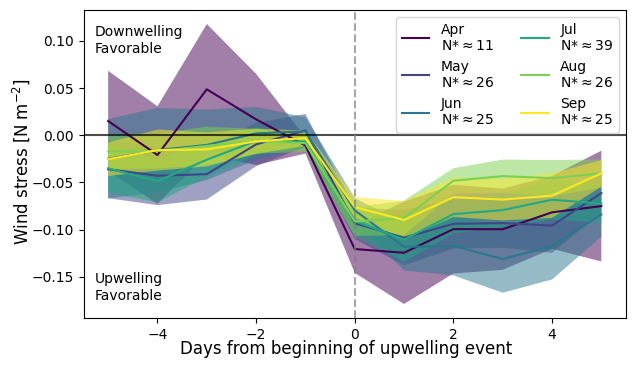

In [17]:
composite_stress_monthly = composite(
    composite_wind_events,
    "coare_y",
    days,
    composite_type=CompositeType.MONTHLY,
)

fig, ax = plt.subplots(sharex=True, sharey=True, figsize=(7, 4))
lines = []
for i, m in enumerate(composite_stress_monthly["month"].sel(month=slice(4, 9))):
    data = composite_stress_monthly.sel(month=m)
    nstar = data["count"].mean(dim="time")
    nstar_string = f"N*$\\approx${nstar:.0f}"
    ax.plot(days, data["mean"], c=colors[i], label=f"{calendar.month_abbr[m.values]}\n{nstar_string}")
    ax.fill_between(
        days,
        data["mean"] - data["ci"],  # pyright: ignore[reportArgumentType]
        data["mean"] + data["ci"],  # pyright: ignore[reportArgumentType]
        ls="None",
        edgecolor="None",
        facecolor=colors[i],
        alpha=0.5,
    )

ax.minorticks_off()
ax.axhline(0, color="black", lw=1.5, ls="-", alpha=0.7)
ax.axvline(0, color="gray", lw=1.5, ls="--", alpha=0.7)
ax.legend(ncol=2, loc="upper right")

ax.text(
    0.02,
    0.05,
    "Upwelling\nFavorable",
    bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    zorder=2,
)
ax.text(
    0.02,
    0.95,
    "Downwelling\nFavorable",
    bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    transform=ax.transAxes,
    va="top",
    ha="left",
    zorder=2,
)

fig.supylabel("Wind stress [$\\mathsf{N} \\; \\mathsf{m^{-2}}$]")
fig.supxlabel("Days from beginning of upwelling event")
plt.savefig(FIGURES_DIR / "manuscript/composite_wind_stress.pdf", format="pdf")

In [18]:
composite_vel_monthly_cs = composite(
    composite_vel_events,
    "cs",
    days,
    composite_type=CompositeType.MONTHLY,
)

Text(0.5, 0.98, 'Cross-shelf velocity')

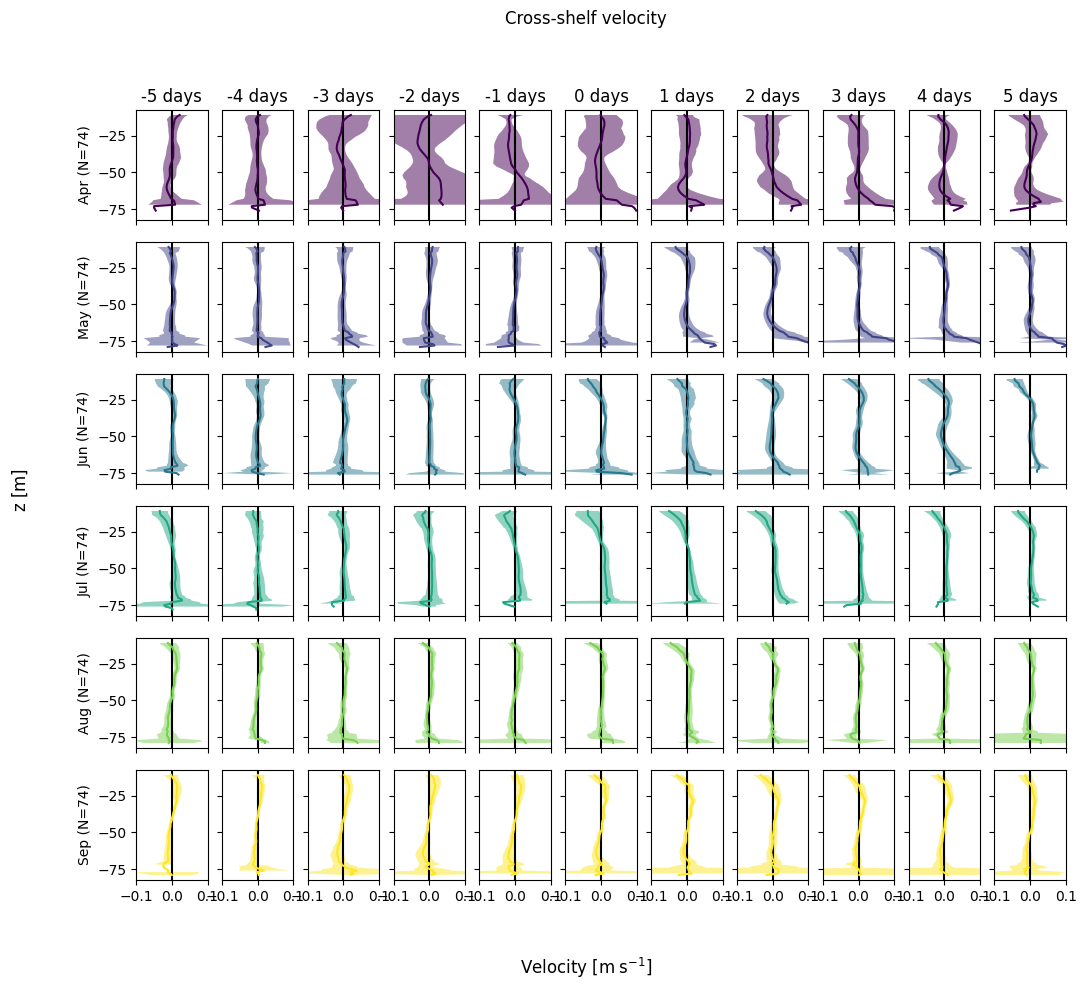

In [19]:
fig, axs = plt.subplots(nrows=6, ncols=11, sharex=True, sharey=True, figsize=(12, 10))
for i, mon in enumerate(composite_vel_monthly_cs["month"].sel(month=slice(4, 9))):
    for j, day in enumerate(days):
        data = composite_vel_monthly_cs.sel(month=mon, time=day)
        axs[i][j].axvline(0, color="black")
        axs[i][j].plot(data["mean"], -data["depth"], c=colors[i])
        axs[i][j].fill_betweenx(
            -data["depth"],
            data["mean"] - data["ci"],
            data["mean"] + data["ci"],
            ls="None",
            edgecolor="None",
            facecolor=colors[i],
            alpha=0.5,
        )
        axs[i][j].set_xlim([-0.1, 0.1])
        if j == 0:
            axs[i][j].set_ylabel(
                f"{calendar.month_abbr[mon.to_numpy()]} (N={np.nanmean(n):.0f})",
            )
        if i == 0:
            axs[i][j].set_title(f"{day} days")
fig.supxlabel("Velocity [$\\mathsf{m \\; s^{-1}}$]")
fig.supylabel("z [$\\mathsf{{m}}$]")
fig.suptitle("Cross-shelf velocity")

Number of events in month Apr: 3
Number of events in month May: 12
Number of events in month Jun: 11
Number of events in month Jul: 8
Number of events in month Aug: 9
Number of events in month Sep: 12


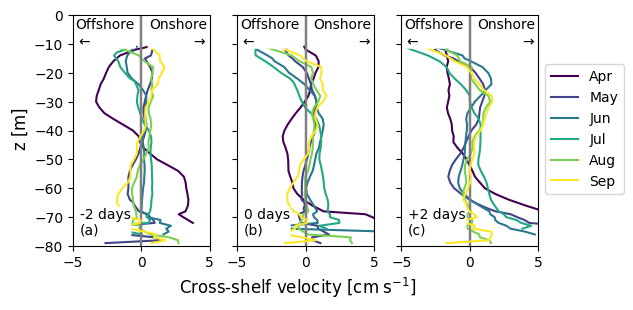

In [32]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(6, 3))
composite_vel_monthly_cs_slice = composite_vel_monthly_cs.sel(
    time=slice(-2, 2, 2),
    month=slice(4, 9),
)


for i, v in enumerate(composite_vel_monthly_cs_slice["time"]):
    for j, m in enumerate(composite_vel_monthly_cs_slice.sel(time=v)["month"]):
        data = composite_vel_monthly_cs_slice.sel(time=v, month=m)
        axs[i].axvline(0, color="gray", lw=1.5)
        axs[i].plot(
            data["mean"] * 100,  # convert to cm/s
            -data["depth"],
            label=calendar.month_abbr[m.values],
            c=colors[j],
        )
        axs[i].minorticks_off()
        axs[i].set_ylim([-80, 0])
        axs[i].set_xlim([-5, 5])
        axs[i].text(
            0.02,
            0.99,
            "Offshore\n$\\leftarrow$",
            bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
            transform=axs[i].transAxes,
            va="top",
            ha="left",
        )
        axs[i].text(
            0.98,
            0.99,
            "Onshore\n$\\rightarrow$",
            bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
            transform=axs[i].transAxes,
            va="top",
            ha="right",
        )
        if i == 0:
            print(
                f"Number of events in month {calendar.month_abbr[m.values]}: {data['count'].mean().values:.0f}",
            )
bbox_props = {"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."}

axs[0].annotate("-2 days\n(a)", xy=(0.05, 0.05), xycoords="axes fraction", fontsize=10, bbox=bbox_props)
axs[1].annotate("0 days\n(b)", xy=(0.05, 0.05), xycoords="axes fraction", fontsize=10, bbox=bbox_props)
axs[2].annotate("+2 days\n(c)", xy=(0.05, 0.05), xycoords="axes fraction", fontsize=10, bbox=bbox_props)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.9, 0.5))

fig.supxlabel("Cross-shelf velocity [$\\mathsf{cm \\; s^{-1}}$]", y=-0.07)
fig.supylabel("z [$\\mathsf{{m}}$]", x=0.02)
plt.savefig(
    FIGURES_DIR / "manuscript/composite_cs_velocity.pdf",
    format="pdf",
    bbox_inches="tight",
)

In [21]:
composite_vel_monthly_as = composite(
    composite_vel_events,
    "as",
    days,
    composite_type=CompositeType.MONTHLY,
)

Text(0.5, 0.98, 'Along-shelf velocity')

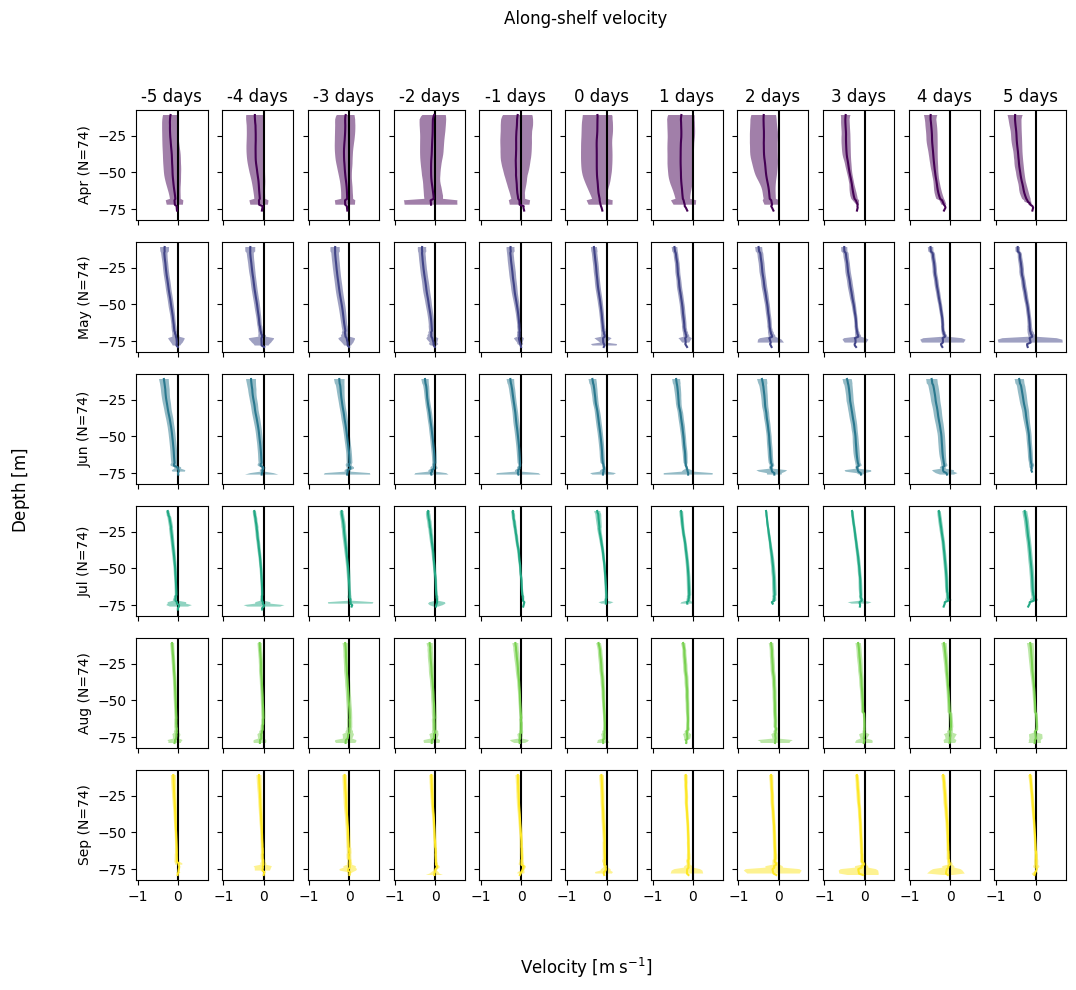

In [22]:
fig, axs = plt.subplots(nrows=6, ncols=11, sharex=True, sharey=True, figsize=(12, 10))
for i, d in enumerate(composite_vel_monthly_as["month"].sel(month=slice(4, 9))):
    for j, day in enumerate(days):
        data = composite_vel_monthly_as.sel(month=d, time=day)
        axs[i][j].axvline(0, color="black")
        axs[i][j].plot(data["mean"], -data["depth"], c=colors[i])
        axs[i][j].fill_betweenx(
            -data["depth"],
            data["mean"] - data["ci"],
            data["mean"] + data["ci"],
            ls="None",
            edgecolor="None",
            facecolor=colors[i],
            alpha=0.5,
        )
        # axs[i][j].plot(data['mean'] + data['ci'], -data['depth'], '--', c=cmap(j/11))
        # axs[i][j].plot(data['mean'] - data['ci'], -data['depth'], '--', c=cmap(j/11))
        # axs[i][j].set_xlim([-0.1, 0.1])
        if j == 0:
            axs[i][j].set_ylabel(
                calendar.month_abbr[data["month"].values] + f" (N={np.nanmean(n):.0f})",
            )
        if i == 0:
            axs[i][j].set_title(f"{day} days")
fig.supxlabel("Velocity [$\\mathsf{m \\; s^{-1}}$]")
fig.supylabel("Depth [$\\mathsf{m}$]")
fig.suptitle("Along-shelf velocity")

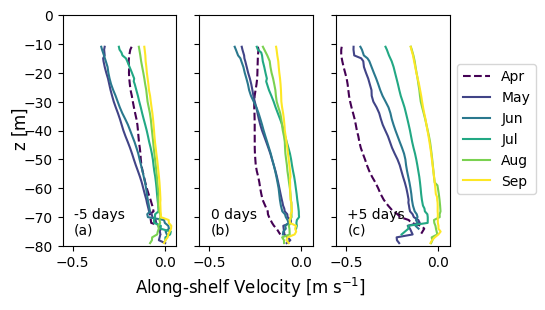

In [23]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(5, 3))
composite_vel_monthly_as_slice = composite_vel_monthly_as.sel(
    time=slice(-5, 5, 5),
    month=slice(4, 9),
)

for i, v in enumerate(composite_vel_monthly_as_slice["time"]):
    for j, m in enumerate(composite_vel_monthly_as_slice.sel(time=v)["month"]):
        data = composite_vel_monthly_as_slice.sel(time=v, month=m)
        if j == 0:
            axs[i].plot(
                data["mean"],
                -data["depth"],
                label=calendar.month_abbr[m.values],
                c=colors[j],
                ls="--",
            )
        else:
            axs[i].plot(
                data["mean"],
                -data["depth"],
                label=calendar.month_abbr[m.values],
                c=colors[j],
            )
        axs[i].minorticks_off()
        axs[i].set_ylim([-80, 0])

axs[0].annotate("-5 days\n(a)", xy=(0.10, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("0 days\n(b)", xy=(0.10, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("+5 days\n(c)", xy=(0.10, 0.05), xycoords="axes fraction", fontsize=10)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.9, 0.5))

fig.supxlabel("Along-shelf Velocity [$\\mathsf{m \\; s^{-1}}$]", y=-0.07)
fig.supylabel("z [$\\mathsf{{m}}$]", x=0.02)
plt.savefig(
    FIGURES_DIR / "manuscript/composite_as_velocity.pdf",
    format="pdf",
    bbox_inches="tight",
)

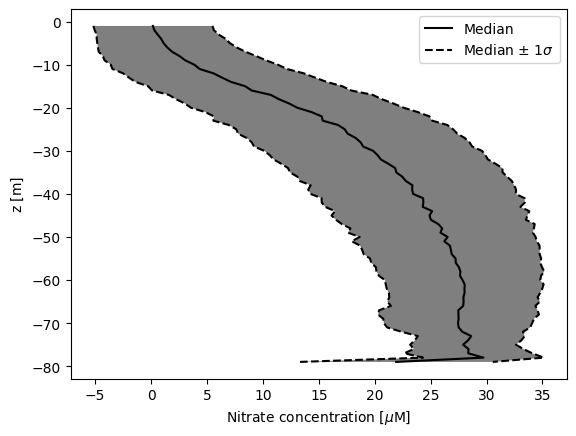

In [24]:
midshelf_nitrate_med = midshelf_nitrate.median(dim="time")
midshelf_nitrate_std = midshelf_nitrate.std(dim="time")
plt.plot(
    midshelf_nitrate_med.nitrate,
    -midshelf_nitrate_med.depth,
    color="black",
    label="Median",
)
plt.fill_betweenx(
    -midshelf_nitrate_med.depth,
    midshelf_nitrate_med.nitrate - midshelf_nitrate_std.nitrate,
    midshelf_nitrate_med.nitrate + midshelf_nitrate_std.nitrate,
    ls="None",
    edgecolor="None",
    facecolor="black",
    alpha=0.5,
)
plt.plot(
    midshelf_nitrate_med.nitrate - midshelf_nitrate_std.nitrate,
    -midshelf_nitrate_med.depth,
    "--",
    color="black",
    label=r"Median $\pm$ 1$\sigma$",
)
plt.plot(
    midshelf_nitrate_med.nitrate + midshelf_nitrate_std.nitrate,
    -midshelf_nitrate_med.depth,
    "--",
    color="black",
)
plt.xlabel("Nitrate concentration [$\\mu \\mathsf{{M}}$]")
plt.ylabel("z [$\\mathsf{{m}}$]")
plt.legend()

In [25]:
MINIMUM_N_STAR = 5
midshelf_nitrate_monthly = xr.Dataset(
    {
        "mean": midshelf_nitrate.groupby("time.month").mean(dim="time", skipna=True)["nitrate"],
        "std": midshelf_nitrate.groupby("time.month").std(dim="time", skipna=True)["nitrate"],
        "count": midshelf_nitrate.groupby("time.month").count(dim="time")["nitrate"],
    },
)
midshelf_nitrate_monthly["ci"] = midshelf_nitrate_monthly["std"] / np.sqrt(5) * distributions.t(5 - 1).isf(0.025)
midshelf_nitrate_monthly = midshelf_nitrate_monthly.where(
    midshelf_nitrate_monthly["count"] / 7 >= MINIMUM_N_STAR,  # N* at least ~5
)

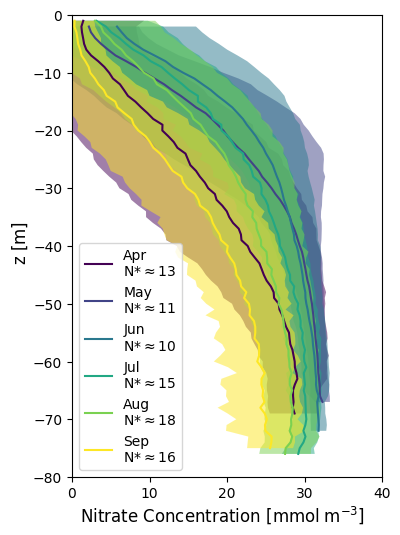

In [26]:
fig, ax = plt.subplots(sharex=True, sharey=True, figsize=(4, 6))
for i, m in enumerate(range(4, 10)):
    monthly_data = midshelf_nitrate_monthly.isel(month=m)
    ax.plot(
        monthly_data["mean"],
        -monthly_data["depth"],
        color=colors[i],
        label=f"{calendar.month_abbr[m]}\nN*$\\approx${np.ceil(monthly_data['count'].mean().values / 7):.0f}",
    )
    ax.fill_betweenx(
        -monthly_data["depth"],
        monthly_data["mean"] - monthly_data["ci"],  # pyright: ignore[reportArgumentType]
        monthly_data["mean"] + monthly_data["ci"],  # pyright: ignore[reportArgumentType]
        ls="None",
        edgecolor="None",
        facecolor=colors[i],
        alpha=0.5,
    )

    ax.set_xlim(0, 40)
    ax.set_ylim(-80, 0)
    ax.minorticks_off()

ax.legend()
fig.supxlabel("Nitrate Concentration [$\\mathsf{m mol \\; m^{-3}}$]", y=0.03)
fig.supylabel("z [$\\mathsf{{m}}$]", x=-0.03)
plt.savefig(
    FIGURES_DIR / "manuscript/monthly_midshelf_nitrate.pdf",
    format="pdf",
    bbox_inches="tight",
)

In [27]:
composite_midshelf_nitrate_flux_monthly = midshelf_nitrate_monthly * composite_vel_monthly_cs
midshelf_velocity_nitrate_cov = xr.cov(
    midshelf_nitrate["nitrate"],
    velocity["cs"],
    ["time"],
)
composite_midshelf_nitrate_flux_monthly["std"] = np.sqrt(
    (midshelf_nitrate_monthly["mean"] * composite_vel_monthly_cs["std"]) ** 2
    + (composite_vel_monthly_cs["mean"] * midshelf_nitrate_monthly["std"]) ** 2
    + 2 * midshelf_nitrate_monthly["mean"] * composite_vel_monthly_cs["mean"] * midshelf_velocity_nitrate_cov,
)
composite_midshelf_nitrate_flux_monthly["count"] = composite_vel_monthly_cs["count"]
composite_midshelf_nitrate_flux_monthly = composite_midshelf_nitrate_flux_monthly.transpose(
    *composite_vel_monthly_cs["count"].dims,
)
composite_midshelf_nitrate_flux_monthly["ci"] = (
    composite_midshelf_nitrate_flux_monthly["std"]
    / np.sqrt(composite_midshelf_nitrate_flux_monthly["count"])
    * distributions.t(composite_midshelf_nitrate_flux_monthly["count"] - 1).isf(0.025)
)

c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\xarray\computation\apply_ufunc.py:814: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


Text(0.5, 0.98, 'Cross-shelf Nitrate Flux')

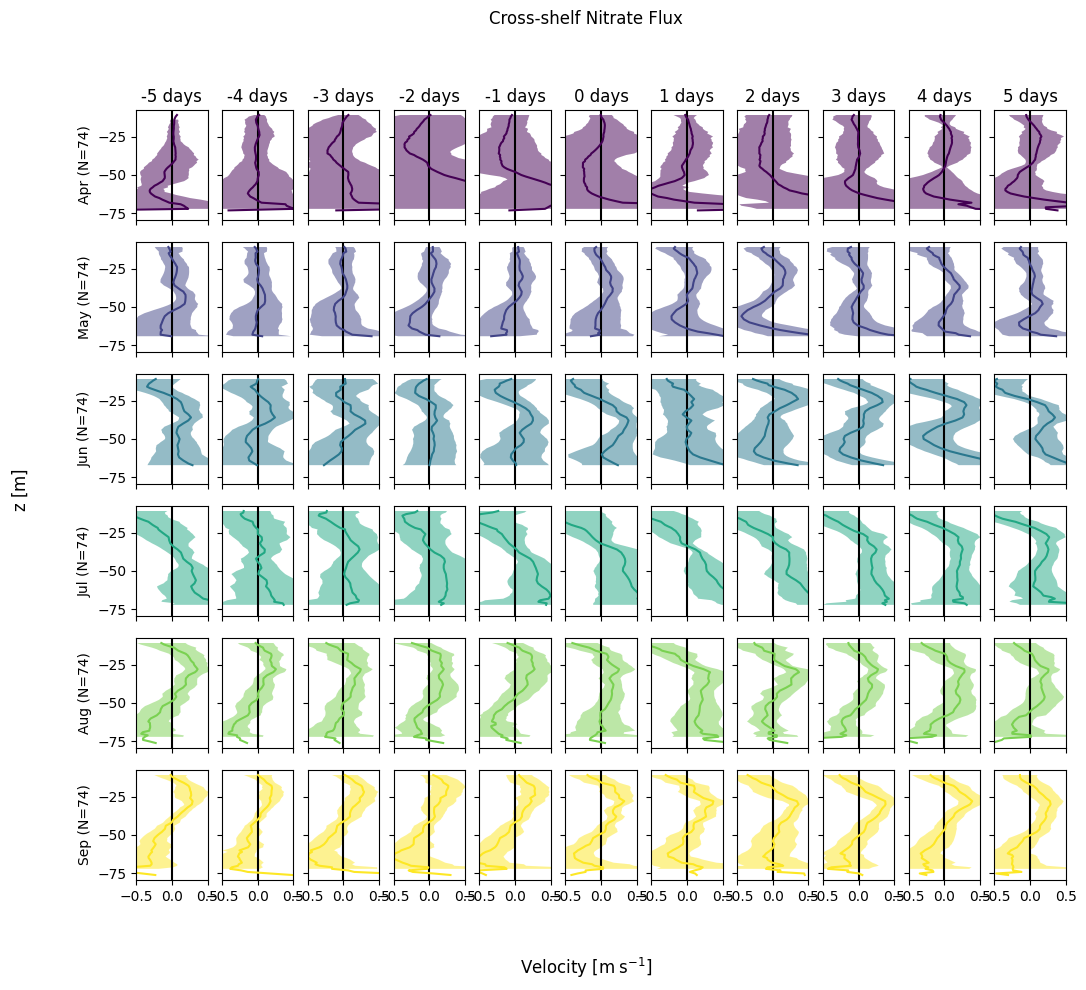

In [28]:
fig, axs = plt.subplots(nrows=6, ncols=11, sharex=True, sharey=True, figsize=(12, 10))
for i, d in enumerate(
    composite_midshelf_nitrate_flux_monthly["month"].sel(month=slice(4, 9)),
):
    for j, day in enumerate(days):
        data = composite_midshelf_nitrate_flux_monthly.sel(month=d, time=day)
        axs[i][j].axvline(0, color="black")
        axs[i][j].plot(data["mean"], -data["depth"], c=colors[i])
        axs[i][j].fill_betweenx(
            -data["depth"],
            data["mean"] - data["ci"],
            data["mean"] + data["ci"],
            ls="None",
            edgecolor="None",
            facecolor=colors[i],
            alpha=0.5,
        )
        # axs[i][j].plot(data['mean'] + data['ci'], -data['depth'], '--', c=cmap(j/11))
        # axs[i][j].plot(data['mean'] - data['ci'], -data['depth'], '--', c=cmap(j/11))
        axs[i][j].set_xlim([-0.5, 0.5])
        if j == 0:
            axs[i][j].set_ylabel(
                calendar.month_abbr[data["month"].values] + f" (N={np.nanmean(n):.0f})",
            )
        if i == 0:
            axs[i][j].set_title(f"{day} days")
fig.supxlabel("Velocity [$\\mathsf{m \\; s^{-1}}$]")
fig.supylabel("z [$\\mathsf{{m}}$]")
fig.suptitle("Cross-shelf Nitrate Flux")

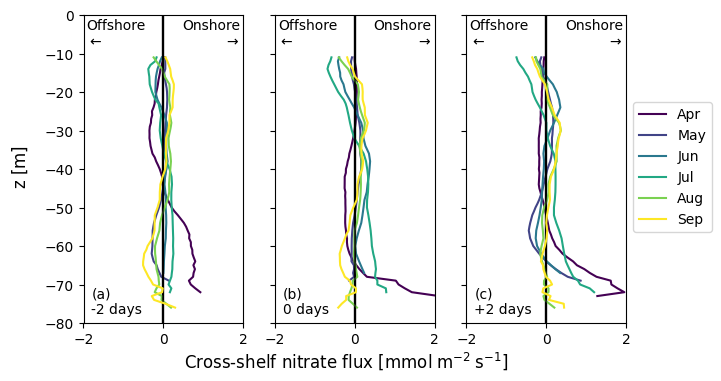

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharex=True, sharey=True, figsize=(7, 4))
composite_midshelf_nitrate_flux_monthly_slice = composite_midshelf_nitrate_flux_monthly.sel(
    time=slice(-2, 2, 2),
    month=slice(4, 9),
)

for i, v in enumerate(composite_midshelf_nitrate_flux_monthly_slice["time"]):
    for j, m in enumerate(
        composite_midshelf_nitrate_flux_monthly_slice.sel(time=v)["month"],
    ):
        data = composite_midshelf_nitrate_flux_monthly_slice.sel(time=v, month=m)
        axs[i].axvline(0, color="black", lw=1.5, ls="-", alpha=0.7)
        axs[i].plot(
            data["mean"],
            -data["depth"],
            label=calendar.month_abbr[m.values],
            c=colors[j],
        )
        axs[i].minorticks_off()
        axs[i].set_ylim([-80, 0])
        axs[i].set_xlim([-2, 2])
        axs[i].text(
            0.02,
            0.99,
            "Offshore\n$\\leftarrow$",
            bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
            transform=axs[i].transAxes,
            va="top",
            ha="left",
        )
        axs[i].text(
            0.98,
            0.99,
            "Onshore\n$\\rightarrow$",
            bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
            transform=axs[i].transAxes,
            va="top",
            ha="right",
        )

bbox_props = {"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."}

axs[0].annotate(
    "(a)\n-2 days",
    xy=(0.05, 0.02),
    xycoords="axes fraction",
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=bbox_props,
)
axs[1].annotate(
    "(b)\n0 days",
    xy=(0.05, 0.02),
    xycoords="axes fraction",
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=bbox_props,
)
axs[2].annotate(
    "(c)\n+2 days",
    xy=(0.05, 0.02),
    xycoords="axes fraction",
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=bbox_props,
)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.9, 0.5))

fig.supxlabel(
    "Cross-shelf nitrate flux [$\\mathsf{mmol \\; m^{-2} \\; s^{-1}}$]",
    y=-0.01,
)
fig.supylabel("z [$\\mathsf{{m}}$]", x=0.02)
plt.savefig(
    FIGURES_DIR / "manuscript/composite_cs_nflux.pdf",
    format="pdf",
    bbox_inches="tight",
)

In [30]:
flux_bottom_list = []
flux_middle_list = []
flux_full_list = []
for m in composite_midshelf_nitrate_flux_monthly["month"].to_numpy():
    flux_bottom_list.append(
        composite_midshelf_nitrate_flux_monthly.sel(month=m, depth=slice(60, 70))["mean"]
        .interpolate_na(dim="depth")
        .mean(dim="depth"),
    )

    # 20 m to 40 m flux
    flux_middle_list.append(
        composite_midshelf_nitrate_flux_monthly.sel(month=m, depth=slice(20, 40))["mean"]
        .interpolate_na(dim="depth")
        .mean(dim="depth"),
    )

    # full flux
    flux_full_list.append(
        composite_midshelf_nitrate_flux_monthly.sel(month=m)["mean"].interpolate_na(dim="depth").mean(dim="depth"),
    )

flux_bottom: xr.DataArray = xr.concat(flux_bottom_list, dim="month")
flux_middle: xr.DataArray = xr.concat(flux_middle_list, dim="month")
flux_full: xr.DataArray = xr.concat(flux_full_list, dim="month")

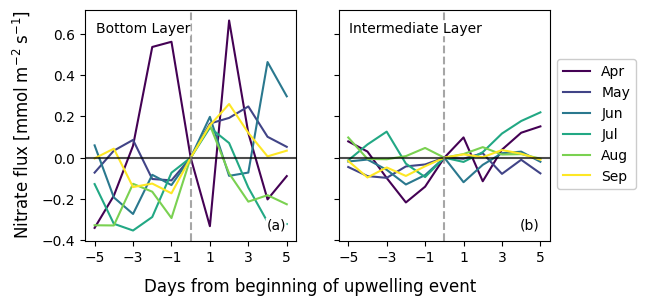

In [31]:
# c = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']
# cmap = cmo.tools.crop_by_percent(cmo.thermal, 30, which='both')
# cmap = cmap.from_list('cmap', cmap(np.linspace(0, 1, 11)), 11)

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(6, 3))
for i, m in enumerate(
    composite_midshelf_nitrate_flux_monthly.sel(month=slice(4, 9))["month"].to_numpy(),
):
    axs[0].plot(
        days,
        flux_bottom.sel(month=m) - flux_bottom.sel(month=m).sel(time=0),
        color=colors[i],
        label=calendar.month_abbr[m],
    )
    axs[1].plot(
        days,
        flux_middle.sel(month=m) - flux_middle.sel(month=m).sel(time=0),
        color=colors[i],
        label=calendar.month_abbr[m],
    )

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.9, 0.5), framealpha=1)
fig.supxlabel("Days from beginning of upwelling event", y=-0.07)
fig.supylabel("Nitrate flux [$\\mathsf{mmol \\; m^{-2} \\; s^{-1}}$]", x=0)

axis_labels = ["Bottom Layer", "Intermediate Layer"]
for i, ax in enumerate(axs):
    ax.minorticks_off()
    ax.axhline(0, color="black", ls="-", lw=1.5, alpha=0.7)
    ax.axvline(0, color="gray", lw=1.5, ls="--", alpha=0.7)
    ax.annotate(
        f"({string.ascii_lowercase[i]})",
        xy=(0.95, 0.05),
        xycoords="axes fraction",
        fontsize=10,
        ha="right",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    )
    ax.annotate(
        axis_labels[i],
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=10,
        va="top",
        bbox={"facecolor": "white", "alpha": 1, "edgecolor": "white", "boxstyle": "round,pad=0."},
    )
    ax.set_xticks([-5, -3, -1, 1, 3, 5])

plt.savefig(
    FIGURES_DIR / "manuscript/layer_cs_nflux.pdf",
    format="pdf",
    bbox_inches="tight",
)